In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

base = r'C:\Users\pench\Documents\ecommerce-segmentation\data\raw'

orders  = pd.read_csv(f'{base}\\List of Orders.csv')
details = pd.read_csv(f'{base}\\Order Details.csv')

df = pd.merge(orders, details, on='Order ID', how='inner')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print(" Data loaded!")
print(f"Shape: {df.shape}")

 Data loaded!
Shape: (1500, 10)


In [2]:
# Reference date = 1 day after last order
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

rfm = df.groupby('CustomerName').agg(
    Recency   = ('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency = ('Order ID',   'nunique'),
    Monetary  = ('Amount',     'sum')
).reset_index()

print("\n RFM Table Created!")
print(rfm.shape)
rfm.head(10)

Reference date: 2019-04-01 00:00:00

 RFM Table Created!
(332, 4)


,CustomerName,Recency,Frequency,Monetary
0,Aakanksha,274,1,74.0
1,Aarushi,10,3,4701.0
2,Aashna,118,1,1931.0
3,Aastha,157,1,3276.0
4,Aayush,137,1,556.0
5,Aayushi,64,3,689.0
6,Abhijeet,142,2,5691.0
7,Abhijit,111,1,78.0
8,Abhishek,115,5,8135.0
9,Adhvaita,268,1,193.0


In [4]:
# Score 5 = Best, 1 = Worst
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

print(" RFM Scores added!")
rfm[['CustomerName','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Total']].head(10)

 RFM Scores added!


,CustomerName,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total
0,Aakanksha,274,1,74.0,1,1,1,3
1,Aarushi,10,3,4701.0,5,5,5,15
2,Aashna,118,1,1931.0,3,1,4,8
3,Aastha,157,1,3276.0,2,1,5,8
4,Aayush,137,1,556.0,3,1,3,7
5,Aayushi,64,3,689.0,4,5,3,12
6,Abhijeet,142,2,5691.0,3,4,5,12
7,Abhijit,111,1,78.0,3,1,1,5
8,Abhishek,115,5,8135.0,3,5,5,13
9,Adhvaita,268,1,193.0,1,1,2,4


In [5]:
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Total'].apply(segment_customer)

print("Customer Segment Distribution:")
print(rfm['Segment'].value_counts())
print(f"\nTotal customers: {len(rfm)}")

Customer Segment Distribution:
Segment
Potential Loyalists    110
Champions               70
Loyal Customers         67
At Risk                 60
Lost Customers          25
Name: count, dtype: int64

Total customers: 332


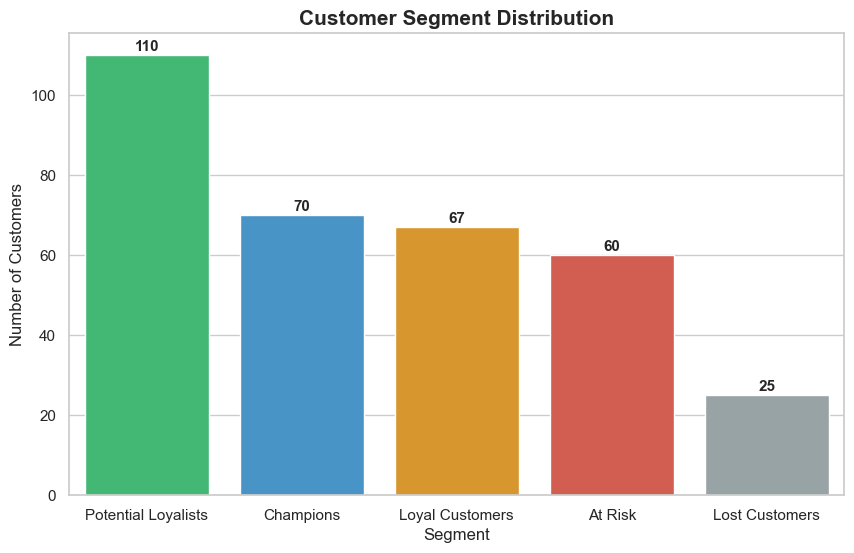

 Plot saved!


In [6]:
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']

plt.figure(figsize=(10,6))
bars = sns.barplot(x=seg_counts.index, y=seg_counts.values,
                   hue=seg_counts.index, palette=colors, legend=False)
for bar, val in zip(bars.patches, seg_counts.values):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 1,
              str(val), ha='center', fontsize=11, fontweight='bold')

plt.title('Customer Segment Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\05_customer_segments.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

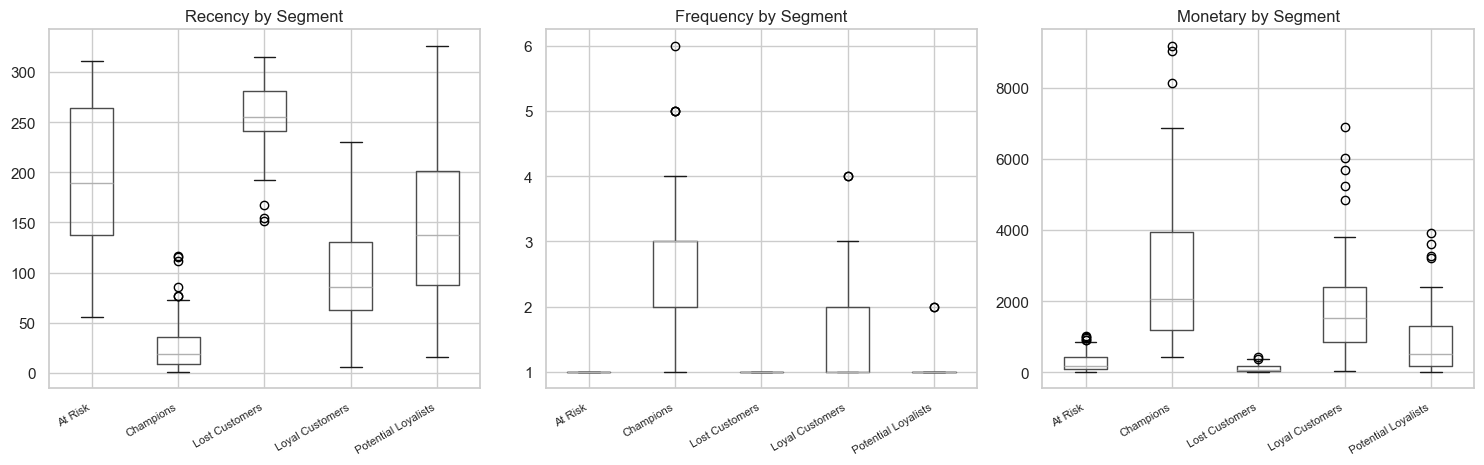

 Plot saved!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rfm.boxplot(column='Recency',   by='Segment', ax=axes[0])
rfm.boxplot(column='Frequency', by='Segment', ax=axes[1])
rfm.boxplot(column='Monetary',  by='Segment', ax=axes[2])

axes[0].set_title('Recency by Segment')
axes[1].set_title('Frequency by Segment')
axes[2].set_title('Monetary by Segment')

for ax in axes:
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right', fontsize=8)

plt.suptitle('')
plt.tight_layout()
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\06_rfm_boxplots.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

In [8]:
import os
os.makedirs(r'C:\Users\pench\Documents\ecommerce-segmentation\data\processed', exist_ok=True)

rfm.to_csv(r'C:\Users\pench\Documents\ecommerce-segmentation\data\processed\rfm_scores.csv',
           index=False)
print(" RFM data saved!")
print(rfm.describe().round(2))

 RFM data saved!
       Recency  Frequency  Monetary  RFM_Total
count   332.00     332.00    332.00     332.00
mean    130.59       1.51   1299.70       9.00
std      89.82       0.88   1577.29       3.29
min       1.00       1.00     11.00       3.00
25%      59.75       1.00    178.50       6.00
50%     118.00       1.00    764.50       8.00
75%     198.00       2.00   1716.50      12.00
max     326.00       6.00   9177.00      15.00
